In [1]:
!pip install pandas_ta

In [2]:
import pandas as pd
import numpy as np
# import pandas_ta
import ta
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv( "C:/Users/DELL/Desktop/UOIT/capstone/AMZN_alpha_2min_2024-05_to_2025-05.csv")

In [4]:
 #Convert 'Timestamp' from object to datetime.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

#check if it is  converted
print( "the data type of 'Timestap' in dataset is", df['Timestamp'].dtype)


the data type of 'Timestap' in dataset is datetime64[ns]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119542 entries, 0 to 119541
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Timestamp  119542 non-null  datetime64[ns]
 1   Open       119542 non-null  float64       
 2   High       119542 non-null  float64       
 3   Low        119542 non-null  float64       
 4   Close      119542 non-null  float64       
 5   Volume     119542 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 5.5 MB


In [6]:
# Define regular trading hours
import datetime
market_open = datetime.time(9, 30)
market_close = datetime.time(16, 0)

# Keep only rows within regular trading hours
df = df[
    (df['Timestamp'].dt.time >= market_open) & 
    (df['Timestamp'].dt.time <= market_close)
].copy()


In [7]:
print(f" First {df.head(1)}")
print(f" Last {df.tail(1)}")

 First               Timestamp     Open   High       Low   Close   Volume
165 2024-05-01 09:30:00  181.635  182.0  179.5907  179.65  2837082
 Last                  Timestamp    Open    High    Low   Close    Volume
119422 2025-04-30 16:00:00  184.32  188.81  183.7  188.11  20396609


In [8]:
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#
#---------------Feature ENgineering----------------#

In [9]:
# RCI_9
def rci(series, period=9):
    result = np.full(len(series), np.nan)
    for i in range(period-1, len(series)):
        price = series[i-period+1:i+1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1  # rank
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff**2)) / (period * (period**2 - 1))) * 100
        result[i] = rci_value
    return result

#  RCI (9 periods) !
df['RCI_9'] = rci(df['Close'], period=14)



# 3. MACD
macd = ta.trend.macd(df['Close'], window_slow=26, window_fast=12)
macd_signal = ta.trend.macd_signal(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd
df['MACD_signal'] = macd_signal
df['MACD_hist'] = macd - macd_signal


# # 7. Relative Strength Index (RSI)
# df['RSI'] = ta.momentum.rsi(df['Close'], window=7, fillna=True)
# # https://choiceindia.com/blog/best-rsi-setting-for-intraday


# # 10. Williams %R !
# df['WilliamsR'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14, fillna=True)
# # https://trendspider.com/learning-center/introduction-to-williams-r-range/

# # 11. Percentage Price Oscillator (PPO) !
# df['PPO'] = ta.momentum.ppo(df['Close'], window_slow=26, window_fast=12, window_sign=9, fillna=True)
# # https://www.investopedia.com/terms/p/ppo.asp


# 13. Stochastic Oscillator
# Calculate %K
# df['Stoch_K'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14, smooth_window=3, fillna=True)


# # 15. Chaikin Money Flow (CMF) !
# def chaikin_money_flow(df, window=20):
#     mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
#     cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
#     return cmf

# df['CMF'] = chaikin_money_flow(df, window=20)
# # https://help.stockdoctor.com.au/hc/en-us/articles/360000099635-Chaikin-Money-Flow


#--------------------Youssef Part-----------------------#
#--------------------Youssef Part-----------------------#
# PSAR ! 
df['PSAR'] = ta.trend.PSARIndicator(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    step=0.02,
    max_step=0.2
).psar()


# Bollinger Bands parameters !
bb_length = 20
bb_std = 2

# Calculate Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=bb_length).mean()
df['BB_Std'] = df['Close'].rolling(window=bb_length).std()
df['BB_Upper'] = df['BB_Middle'] + bb_std * df['BB_Std']
df['BB_Lower'] = df['BB_Middle'] - bb_std * df['BB_Std']


# SMA parameters !
sma_length = 20
df['SMA'] = df['Close'].rolling(window=sma_length).mean()


# Envelope parameters !
ma_length = 20
envelope_pct = 0.02
df['SMA_Envelope'] = df['Close'].rolling(window=ma_length).mean()
# df['Upper_Envelope'] = df['SMA_Envelope'] * (1 + envelope_pct)
# df['Lower_Envelope'] = df['SMA_Envelope'] * (1 - envelope_pct)


# AO parameters !
# Calculate median price
df['Median_Price'] = (df['High'] + df['Low']) / 2
df['AO'] = df['Median_Price'].rolling(window=5).mean() - df['Median_Price'].rolling(window=34).mean()


# CMO with 14-period !
def cmo(series, window=14):
    diff = series.diff()
    up = diff.clip(lower=0).fillna(0)
    down = -diff.clip(upper=0).fillna(0)
    sum_up = up.rolling(window=window).sum()
    sum_down = down.rolling(window=window).sum()
    cmo_val = 100 * (sum_up - sum_down) / (sum_up + sum_down)
    return cmo_val

df['CMO'] = cmo(df['Close'], window=14)



# # StdDev parameters !
# std_length = 20

# # Calculate SMA and StdDev over the period
# # df['SMA_Std'] = df['Close'].rolling(window=std_length).mean()
# df['STD_Std'] = df['Close'].rolling(window=std_length).std()


# # Ichimoku !
# ichimoku = ta.trend.IchimokuIndicator(
#     high=df['High'],
#     low=df['Low'],
#     window1=9,    # Tenkan-sen
#     window2=26,   # Kijun-sen
#     window3=52,   # Senkou Span B
#     visual=False  # If True, returns only lines for plotting
# )

# df['Tenkan_Sen'] = ichimoku.ichimoku_conversion_line()
# df['Kijun_Sen'] = ichimoku.ichimoku_base_line()
# df['Senkou_Span_A'] = ichimoku.ichimoku_a()
# df['Senkou_Span_B'] = ichimoku.ichimoku_b()
# df['Chikou_Span'] = df['Close'].shift(-26)



# # ADX
# adx_indicator = ta.trend.ADXIndicator(
#     high=df['High'],
#     low=df['Low'],
#     close=df['Close'],
#     window=14,  # adx_length
#     fillna=False
# )
# df['Plus_DI'] = adx_indicator.adx_pos()
# df['Minus_DI'] = adx_indicator.adx_neg()
# df['ADX'] = adx_indicator.adx()


14. #Internal Bar Strength (IBS)
df['IBS'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])

# # Envelope 
# env_length = 20    # period
# env_dev = 0.02     # 2% band

# df['Envelope_SMA'] = df['Close'].rolling(window=env_length).mean()
# df['Envelope_Upper'] = df['Envelope_SMA'] * (1 + env_dev)

In [10]:
# drop NaN from both datasets
df = df.dropna().reset_index(drop=True)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp       0
Open            0
High            0
Low             0
Close           0
Volume          0
RCI_9           0
MACD            0
MACD_signal     0
MACD_hist       0
PSAR            0
BB_Middle       0
BB_Std          0
BB_Upper        0
BB_Lower        0
SMA             0
SMA_Envelope    0
Median_Price    0
AO              0
CMO             0
IBS             0
dtype: int64


In [11]:
pd.set_option('display.max_columns', None)  # Show all columns in output
df.head(5)

,Timestamp,Open,High,Low,Close,Volume,RCI_9,MACD,MACD_signal,MACD_hist,PSAR,BB_Middle,BB_Std,BB_Upper,BB_Lower,SMA,SMA_Envelope,Median_Price,AO,CMO,IBS
0,2024-05-01 10:36:00,180.680,180.96,180.67,180.9490,437138,-92.967033,0.025918,-0.081651,0.107569,178.920000,180.183695,0.599715,181.383126,178.984264,180.183695,180.183695,180.815,-0.145295,29.425157,0.962069
1,2024-05-01 10:38:00,180.940,181.02,180.74,180.9700,350842,-93.406593,0.079424,-0.049436,0.128860,178.960800,180.160195,0.555472,181.271140,179.049250,180.160195,180.160195,180.880,0.034215,61.052632,0.821429
2,2024-05-01 10:40:00,180.965,181.06,180.68,180.7700,427611,-92.087912,0.104486,-0.018652,0.123137,179.043168,180.140695,0.524509,181.189713,179.091677,180.140695,180.140695,180.870,0.139063,58.275862,0.236842
3,2024-05-01 10:42:00,180.790,180.79,180.33,180.4799,384324,-87.692308,0.099788,0.005036,0.094752,179.164178,180.124690,0.507955,181.140599,179.108781,180.124690,180.124690,180.560,0.204690,30.073044,0.325870
4,2024-05-01 10:44:00,180.490,180.80,180.37,180.3950,302127,-81.978022,0.088197,0.021669,0.066529,179.277927,180.134940,0.511399,181.157737,179.112143,180.134940,180.134940,180.585,0.226737,21.912351,0.058140


In [12]:
eng_features = ['RCI_9',  'PSAR', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_Middle', 'BB_Std', 'BB_Upper','BB_Lower', 'SMA_Envelope',  'SMA', 'Median_Price', 'AO', 'CMO', 'IBS']

print("Number of eng_features are ", len(eng_features))
print(eng_features)

Number of eng_features are  15
['RCI_9', 'PSAR', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'SMA_Envelope', 'SMA', 'Median_Price', 'AO', 'CMO', 'IBS']


In [13]:

# df = df.dropna().reset_index(drop=True)
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp       0
Open            0
High            0
Low             0
Close           0
Volume          0
RCI_9           0
MACD            0
MACD_signal     0
MACD_hist       0
PSAR            0
BB_Middle       0
BB_Std          0
BB_Upper        0
BB_Lower        0
SMA             0
SMA_Envelope    0
Median_Price    0
AO              0
CMO             0
IBS             0
dtype: int64


In [14]:
#------------------Normalization------------------#
#------------------Normalization------------------#
#------------------Normalization------------------#


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[eng_features] = scaler.fit_transform(df[eng_features])

In [16]:
# Define the intrady next return (close-open)/open.
df['Return'] = (df['Close'].shift(-1) - df['Open'].shift(-1)) / df['Open'].shift(-1)

#create binary direction label (1 if up, 0 if down or flat)
df['Direction'] = (df['Return'] > 0).astype(int)
# df['Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [17]:
n = len(df)
train_end = int(0.60 * n)
validate_end = int(0.70 * n)  # 70%

df_train = df.iloc[:train_end].reset_index(drop=True)
df_validate = df.iloc[train_end:validate_end].reset_index(drop=True)
df_test  = df.iloc[validate_end:].reset_index(drop=True)

print(f"Train set: {df_train.shape}")
print(f"Validation set: {df_validate.shape}")
print(f"Test set: {df_test.shape}")


Train set: (29380, 23)
Validation set: (4896, 23)
Test set: (14691, 23)


In [18]:
# Target variable name
target = 'Direction'

# X/y for Train
X_train = df_train[eng_features].values   # eng_features have been defined previously at the cell of Feature Engineering
y_train = df_train[target].values

# X/y for Validation
X_validate = df_validate[eng_features].values
y_validate = df_validate[target].values

# X/y for Test
X_test = df_test[eng_features].values
y_test = df_test[target].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_validate: {X_validate.shape}, y_validate: {y_validate.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (29380, 15), y_train: (29380,)
X_validate: (4896, 15), y_validate: (4896,)
X_test: (14691, 15), y_test: (14691,)


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping

# ANN 
model = Sequential()
model.add(Dense(15, activation='relu', input_shape=(len(eng_features),))) # number of neurons in input layer is the same as the number of technical indicators
for _ in range(7):  # hidden layers
    model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary output

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy', 'mse'])


# # early stop
early_stop = EarlyStopping(
    monitor='val_accuracy',       
    patience=5,               # stop if no improvement after 5 epochs
    restore_best_weights=True # restores weights from best epoch
)

# train 
history = model.fit(
    X_train, y_train,
    epochs=32,
    batch_size=128,
    validation_data=(X_validate, y_validate),
    callbacks=[early_stop],
    verbose=2
)

# Evaluate on Test
test_loss, test_acc, test_mse = model.evaluate(X_test, y_test)


train_acc = history.history['accuracy'][-1] * 100
train_mse = history.history['mse'][-1]
val_acc = history.history['val_accuracy'][-1] * 100
val_mse = history.history['val_mse'][-1]

print(f"Train Accuracy: {train_acc:.2f}%, Train MSE: {train_mse:.4f}")
print(f"Test Accuracy: {test_acc:.2%}, Test MSE: {test_mse:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%, Validation MSE: {val_mse:.4f}")




Epoch 1/32


D:\Anaconda\envs\notebook-7.3.2\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


230/230 - 3s - 12ms/step - accuracy: 0.5021 - loss: 0.6933 - mse: 0.2501 - val_accuracy: 0.5020 - val_loss: 0.6931 - val_mse: 0.2500
Epoch 2/32
230/230 - 0s - 2ms/step - accuracy: 0.4995 - loss: 0.6933 - mse: 0.2501 - val_accuracy: 0.4953 - val_loss: 0.6933 - val_mse: 0.2501
Epoch 3/32
230/230 - 0s - 2ms/step - accuracy: 0.5021 - loss: 0.6932 - mse: 0.2500 - val_accuracy: 0.4955 - val_loss: 0.6937 - val_mse: 0.2503
Epoch 4/32
230/230 - 0s - 2ms/step - accuracy: 0.5077 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.4910 - val_loss: 0.6937 - val_mse: 0.2503
Epoch 5/32
230/230 - 0s - 2ms/step - accuracy: 0.5040 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.4937 - val_loss: 0.6938 - val_mse: 0.2503
Epoch 6/32
230/230 - 1s - 2ms/step - accuracy: 0.5071 - loss: 0.6930 - mse: 0.2499 - val_accuracy: 0.5045 - val_loss: 0.6933 - val_mse: 0.2501
Epoch 7/32
230/230 - 0s - 2ms/step - accuracy: 0.5067 - loss: 0.6931 - mse: 0.2500 - val_accuracy: 0.4896 - val_loss: 0.6936 - val_mse: 0.2502
Epoch 8/3

In [21]:
#---------Return Calculation-----------#
#---------Return Calculation-----------#
#---------Return Calculation-----------#


In [33]:
fee_per_trade = 0.0004

# Predict probabilities or class labels on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Binary prediction: 1=buy, 0=do nothing

df_test['Predicted'] = y_pred

# Returns on predicted trades 
trade_return = df_test.loc[df_test['Predicted'] == 1, 'Return']
trade_return_with_fee = trade_return - fee_per_trade

total_trade_return = trade_return.sum() 
total_trade_return_with_fee = trade_return_with_fee.sum()

num_trades = len(trade_return)
average_trade_return = trade_return.mean()
average_trade_return_with_fee = trade_return_with_fee.mean()

# Win Rate
win_trades = (trade_return > 0).sum()
winrate = win_trades / num_trades if num_trades > 0 else 0

win_trades_with_fee = (trade_return_with_fee > 0).sum()
winrate_with_fee = win_trades_with_fee / num_trades if num_trades > 0 else 0

# Average Daily Return
df_test['trading_Date'] = pd.to_datetime(df_test['Timestamp']).dt.date
trade_date = df_test.loc[df_test['Predicted'] == 1, ['trading_Date', 'Return']]
trade_date_with_fee = trade_date.copy()
trade_date_with_fee['Return'] = trade_return_with_fee.values

daily_return = trade_date.groupby('trading_Date')['Return'].sum()
average_daily_return = daily_return.mean()

daily_return_with_fee = trade_date_with_fee.groupby('trading_Date')['Return'].sum()
average_daily_return_with_fee = daily_return_with_fee.mean()

# Cumulative Return 
cumulative_return = (np.prod(1 + trade_return) - 1) * 100  # as percent
cumulative_return_with_fee = (np.prod(1 + trade_return_with_fee) - 1) * 100

# Max Drawdown Calculation
cumulative = (1 + trade_return).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min() * 100  # as percent

cumulative_with_fee = (1 + trade_return_with_fee).cumprod()
running_max_with_fee = cumulative_with_fee.cummax()
drawdown_with_fee = (cumulative_with_fee - running_max_with_fee) / running_max_with_fee
max_drawdown_with_fee = drawdown_with_fee.min() * 100  # as percent

print("=== No Fee ===")
print(f"Cumulative Return: {cumulative_return:.2f}%")
print(f"Total Sum of Return: {total_trade_return:.4f}")
print(f"Average daily return: {average_daily_return:.4f}")
print(f"Number of trades: {num_trades}")
print(f"Average return per trade: {average_trade_return:.4f}")
print(f"Win rate: {winrate:.2%}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

print("\n=== With Fee ===")
print(f"Cumulative Return: {cumulative_return_with_fee:.2f}%")
print(f"Total Sum of Return: {total_trade_return_with_fee:.4f}")
print(f"Average daily return: {average_daily_return_with_fee:.4f}")
print(f"Average return per trade: {average_trade_return_with_fee:.4f}")
print(f"Win rate: {winrate_with_fee:.2%}")
print(f"Max Drawdown: {max_drawdown_with_fee:.2f}%")


460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step
=== No Fee ===
Cumulative Return: 0.83%
Total Sum of Return: 0.0132
Average daily return: 0.0002
Number of trades: 1856
Average return per trade: 0.0000
Win rate: 47.95%
Max Drawdown: -10.38%

=== With Fee ===
Cumulative Return: -52.01%
Total Sum of Return: -0.7292
Average daily return: -0.0112
Average return per trade: -0.0004
Win rate: 33.19%
Max Drawdown: -52.27%


In [ ]:
print(df_test[['Timestamp', 'Return']].head(10))

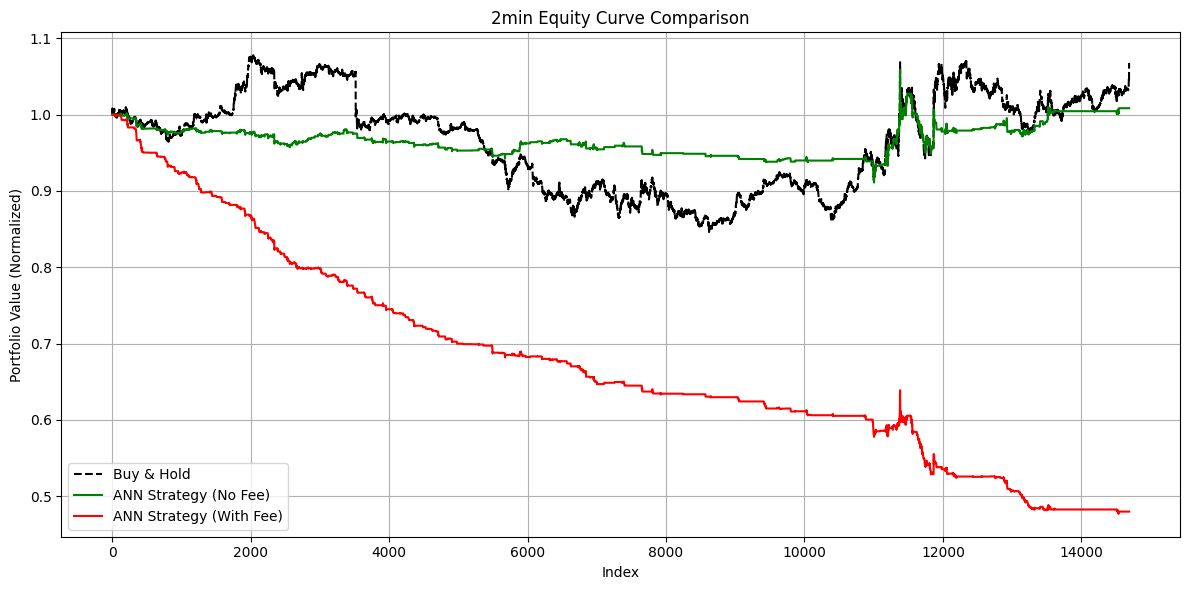

In [34]:
import numpy as np

fee_per_trade = 0.0004 
# Make a copy to avoid modifying the original df_test
returns_strategy = np.where(df_test['Predicted'] == 1, df_test['Return'], 0)
returns_strategy_with_fee = np.where(df_test['Predicted'] == 1, df_test['Return'] - fee_per_trade, 0)

# Buy & Hold (every return in the test set)
buy_hold_equity = (1 + df_test['Return']).cumprod()

# ANN Strategy (No Fee): compound only the predicted trades, else flat (i.e., +0)
strategy_equity_no_fee = (1 + returns_strategy).cumprod()

# ANN Strategy (With Fee): same logic, but subtract fee per trade
strategy_equity_with_fee = (1 + returns_strategy_with_fee).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df_test.index, buy_hold_equity, label='Buy & Hold', linestyle='--', color='black')
plt.plot(df_test.index, strategy_equity_no_fee, label='ANN Strategy (No Fee)', color='green')
plt.plot(df_test.index, strategy_equity_with_fee, label='ANN Strategy (With Fee)', color='red')
plt.title('2min Equity Curve Comparison')
plt.xlabel('Date' if isinstance(df_test.index[0], pd.Timestamp) else 'Index')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
